In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from datasets import load_dataset

import spacy

import re

from gensim.models import Word2Vec

import warnings 
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
dataset = load_dataset("dair-ai/emotion")

train_dataset = pd.DataFrame(dataset['train'])
test_dataset = pd.DataFrame(dataset['test'])
val_dataset = pd.DataFrame(dataset['validation'])

df = pd.concat([train_dataset, test_dataset, val_dataset], ignore_index=True)

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns}')
df.head()

Shape: (20000, 2)
Columns: Index(['text', 'label'], dtype='str')


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [3]:
nlp = spacy.load('en_core_web_sm',disable=['parser','ner','textcat'])

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['text'].apply(clean_text)
texts = df['cleaned_text'].tolist()

docs = nlp.pipe(texts,batch_size=512, n_process=1)


tokens = []
for doc in docs:
    tokens.append([
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.is_space
        and len(token.lemma_) > 1
    ])
df['tokens'] = tokens

print(f"Before: {df['text'][0][:100]}")
print(f"After: {df['cleaned_text'][0][:100]}")
print(f"Tokens: {df['tokens'][0][:10]}")

Before: i didnt feel humiliated
After: i didnt feel humiliated
Tokens: ['not', 'feel', 'humiliated']


In [4]:
embedding_dim = 100

model = Word2Vec(
    sentences=df['tokens'].tolist(),
    vector_size=embedding_dim,
    epochs=10,
    sg=1,
    window=5,
    min_count=2,
    workers=4
)

vocab = model.wv.key_to_index
vocab_size = len(vocab) + 2
print(f'Vocab_Size: {vocab_size}')

embedding_matrix = np.zeros((vocab_size, embedding_dim))

word2idx = {'<PAD>':0, '<UNK>':1}

for word in vocab:
    idx = len(word2idx)
    word2idx[word] = idx
    embedding_matrix[idx] = model.wv[word]

print(f'Embedding Matrix Shape: {embedding_matrix.shape}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocab_Size: 6500
Embedding Matrix Shape: (6500, 100)


In [5]:
max_len = 200

def text_to_sequence(tokens):
    seq = [word2idx.get(t, 1) for t in tokens]
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

df['sequence'] = df['tokens'].apply(text_to_sequence)

print(f'Max_Len: {max_len}')
print(f"Example:  {df['sequence'][0][:15]}...")

Max_Len: 200
Example:  [4, 2, 1052, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...


In [6]:
x = np.array(df['sequence'].tolist())
y = np.array(df['label'].tolist())

xtrain, xtest, ytrain, ytest = train_test_split(
    x, y,
    random_state=42,
    test_size=0.2
)
print(f"Train: {xtrain.shape} | Test: {xtest.shape}")

Train: (16000, 200) | Test: (4000, 200)


In [7]:
class emo_dataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_dataset = emo_dataset(xtrain, ytrain)
test_dataset = emo_dataset(xtest, ytest)

train_loadder = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loadder = DataLoader(
    test_dataset,
    batch_size=32
)

print(f'Train Batches {len(train_loadder)} | Test Batches: {len(test_loadder)}')

Train Batches 500 | Test Batches: 125


In [8]:
class NET(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix,  
                 hidden_dim=64, n_layers=2):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = True

        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers    = n_layers,  
            batch_first   = True,
            dropout       = 0.3,
            bidirectional = True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 6),    
                            
        )

    def forward(self, x):        
        embedded                  = self.embedding(x)
        lstm_out, (hidden, _)     = self.lstm(embedded)
        hidden_fwd                = hidden[-2]
        hidden_bwd                = hidden[-1]
        combined                  = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        return self.classifier(combined)  


HIDDEN_DIM = 64
N_LAYERS   = 2

model = NET(
    vocab_size       = vocab_size,
    embedding_dim    = embedding_dim,   
    embedding_matrix = embedding_matrix,
    hidden_dim       = HIDDEN_DIM,
    n_layers         = N_LAYERS,         
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {total_params:,}")

NET(
  (embedding): Embedding(6500, 100, padding_idx=0)
  (lstm): LSTM(100, 64, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=6, bias=True)
  )
)
Total parameters: 859,478


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(10):

    # ── Train ──
    model.train()
    batch_losses, batch_preds, batch_labels = [], [], []

    for X_batch, y_batch in train_loadder:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_losses.append(loss.item())
        batch_preds.extend(pred.argmax(dim=1).cpu().numpy())  
        batch_labels.extend(y_batch.cpu().numpy())

    train_loss = np.mean(batch_losses)
    train_acc  = accuracy_score(batch_labels, batch_preds)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ── Eval ──
    model.eval()
    batch_losses, batch_preds, batch_labels = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loadder:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            batch_losses.append(loss.item())
            batch_preds.extend(pred.argmax(dim=1).cpu().numpy())  
            batch_labels.extend(y_batch.cpu().numpy())

    test_loss = np.mean(batch_losses)
    test_acc  = accuracy_score(batch_labels, batch_preds)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:2d} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2%} | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.2%}")

Epoch  1 | Train Loss: 1.2640 Acc: 46.34% | Test Loss: 0.6575 Acc: 72.58%
Epoch  2 | Train Loss: 0.4869 Acc: 81.93% | Test Loss: 0.3393 Acc: 87.52%
Epoch  3 | Train Loss: 0.2547 Acc: 91.59% | Test Loss: 0.2896 Acc: 89.72%
Epoch  4 | Train Loss: 0.1806 Acc: 93.92% | Test Loss: 0.3284 Acc: 90.40%
Epoch  5 | Train Loss: 0.1386 Acc: 95.29% | Test Loss: 0.3328 Acc: 90.70%
Epoch  6 | Train Loss: 0.1168 Acc: 96.12% | Test Loss: 0.3424 Acc: 90.65%
Epoch  7 | Train Loss: 0.0941 Acc: 96.50% | Test Loss: 0.3413 Acc: 90.53%
Epoch  8 | Train Loss: 0.0845 Acc: 97.17% | Test Loss: 0.5156 Acc: 90.25%
Epoch  9 | Train Loss: 0.0739 Acc: 97.50% | Test Loss: 0.4846 Acc: 90.53%
Epoch 10 | Train Loss: 0.0584 Acc: 98.10% | Test Loss: 0.5009 Acc: 90.08%


Accuracy: 90.08%

Classification Report:
              precision    recall  f1-score   support

           0     0.9432    0.9488    0.9460      1173
           1     0.9331    0.9164    0.9246      1339
           2     0.7938    0.7701    0.7818       335
           3     0.9149    0.9030    0.9089       536
           4     0.8462    0.8406    0.8434       458
           5     0.6939    0.8553    0.7662       159

    accuracy                         0.9008      4000
   macro avg     0.8542    0.8724    0.8618      4000
weighted avg     0.9025    0.9008    0.9012      4000



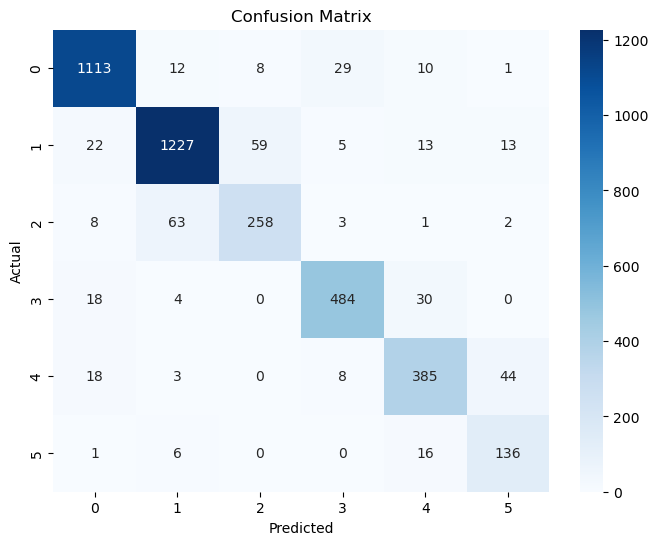

In [10]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loadder:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)          
        preds = outputs.argmax(dim=1)     
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {acc:.2%}")

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    digits=4
))

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),

    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim,
    'hidden_dim': HIDDEN_DIM,
    'n_layers': N_LAYERS,

    'word2idx': word2idx,
    'embedding_matrix': embedding_matrix
}

torch.save(checkpoint, 'emotion_model.pth')

print("Model saved successfully!")

Model saved successfully!
